# The Attention Layer

Read tutorial notes here: [The_Attention_Layer.m](The_Attention_Layer.md)


---
## 1. A scene, patches, and tokens

Attention operates on tokens. To think about projections, we need tokens whose
dimensions mean something. Here, we build a small scene, and represent each patch
by the following code vector:

$$
\mathbf{t} = \big[\;\underbrace{R,\ G,\ B}_{\text{mean color}},\;\;
\underbrace{x,\ y}_{\text{position}},\;\;
\underbrace{\|p\|^2}_{x^2 + y^2},\;\;
\underbrace{1}_{\text{constant}}\;\big]^{\mathsf{T}}
\;\in\; \mathbb{R}^{7 \times 1}
$$

The vector's content is as follows:

| Entry | Description |
|---|---|
| $R,\ G,\ B$ | the patch's mean color, centered on the image's average and then scaled to unit length. |
| $x,\ y$ | the patch's center on the grid, scaled to $[-1, 1]$ |
| $\lVert p \rVert^2$ | $x^2 + y^2$, the squared distance from the middle of the image |
| $1$ | a constant, the same in every token |


**On the two last components of the token vector**. The reason for the last two token dimensions will become clearer later in this notebook, when we design the score of the second attention head, which will attend to the proximity of the patch to its neighbors. For now, we simply point out that we can obtain a (negative) squared distance between two patches by using the bilinear for $\mathbf{t}_i^{\mathsf{T}}\mathbf{S}\mathbf{t}_j$.

$$
-\|p_i - p_j\|^2 \;=\; 2\,(x_i x_j + y_i y_j) \;-\; \|p_i\|^2 \;-\; \|p_j\|^2.
$$


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

np.set_printoptions(precision=2, suppress=True, linewidth=110)
rng = np.random.default_rng(0)

GRID = 8          # 8 x 8 patches
PATCH = 24        # pixels per patch
SIZE = GRID * PATCH


def make_scene():
    """A small scene: sky, grass, two animals, one flower."""
    img = np.zeros((SIZE, SIZE, 3))
    yy, xx = np.mgrid[0:SIZE, 0:SIZE]

    img[yy < SIZE * 0.45] = to_rgb("#8ec5e8")           # sky
    img[yy >= SIZE * 0.45] = to_rgb("#7fa650")          # grass

    def blob(cy, cx, r, color):
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2
        img[mask] = to_rgb(color)

    blob(0.60 * SIZE, 0.25 * SIZE, 0.11 * SIZE, "#8b5a2b")   # animal
    blob(0.70 * SIZE, 0.62 * SIZE, 0.13 * SIZE, "#8b5a2b")   # animal
    blob(0.84 * SIZE, 0.82 * SIZE, 0.14 * SIZE, "#c0392b")   # flower
    return np.clip(img + rng.normal(0, 0.015, img.shape), 0, 1)


image = make_scene()
print(f"image {image.shape}, {GRID}x{GRID} patches of {PATCH}x{PATCH} px -> N = {GRID**2} tokens")

image (192, 192, 3), 8x8 patches of 24x24 px -> N = 64 tokens


In [13]:
FEATURES = ["R", "G", "B", "x", "y", "|p|^2", "1"]
D = len(FEATURES)
N = GRID * GRID


def tokenize(img):
    """One token per patch: mean color, position, squared radius, constant."""
    patches = img.reshape(GRID, PATCH, GRID, PATCH, 3).mean(axis=(1, 3))   # (GRID, GRID, 3)
    color = patches.reshape(N, 3)
    color = color - color.mean(0)                     # center on the image's average color
    color /= np.maximum(np.linalg.norm(color, axis=1, keepdims=True), 1e-8)   # unit length

    gy, gx = np.mgrid[0:GRID, 0:GRID]
    x = (gx.reshape(N) / (GRID - 1)) * 2 - 1             # [-1, 1]
    y = (gy.reshape(N) / (GRID - 1)) * 2 - 1
    r2 = x ** 2 + y ** 2
    ones = np.ones(N)

    return np.column_stack([color, x, y, r2, ones])     # (N, 7), tokens as ROWS


T = tokenize(image)
patch_rgb = image.reshape(GRID, PATCH, GRID, PATCH, 3).mean(axis=(1, 3)).reshape(N, 3)

REGIONS = {"sky": "#8ec5e8", "grass": "#7fa650", "animal": "#8b5a2b", "flower": "#c0392b"}
DEMO_QUERIES = [int(np.linalg.norm(patch_rgb - np.array(to_rgb(hexc)), axis=1).argmin())
                for hexc in REGIONS.values()]
print("one representative patch per region, found by color:")
for name, q in zip(REGIONS, DEMO_QUERIES):
    print(f"  {name:7s} patch {q:2d}  (row {q // GRID}, col {q % GRID})")
print()
print(f"T has shape {T.shape}  (tokens as rows, as in notebook 4 section 3.3)")
print(f"\ncolumns: {FEATURES}")
print(f"\ntoken 0  (top-left, sky):  {T[0]}")
print(f"token 36 (an animal):      {T[36]}")

one representative patch per region, found by color:
  sky     patch  5  (row 0, col 5)
  grass   patch 57  (row 7, col 1)
  animal  patch 44  (row 5, col 4)
  flower  patch 54  (row 6, col 6)

T has shape (64, 7)  (tokens as rows, as in notebook 4 section 3.3)

columns: ['R', 'G', 'B', 'x', 'y', '|p|^2', '1']

token 0  (top-left, sky):  [ 0.03  0.32  0.95 -1.   -1.    2.    1.  ]
token 36 (an animal):      [-0.12 -0.26 -0.96  0.14  0.14  0.04  1.  ]


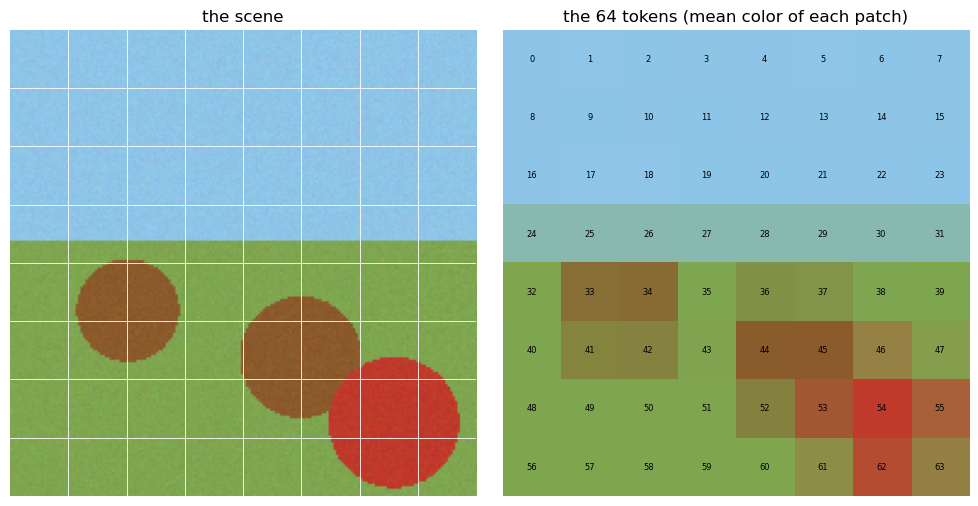

In [14]:
fig, (ax_img, ax_patch) = plt.subplots(1, 2, figsize=(10, 5))
ax_img.imshow(image); ax_img.set_title("the scene"); ax_img.axis("off")
for k in range(1, GRID):
    ax_img.axhline(k * PATCH - 0.5, c="w", lw=0.6)
    ax_img.axvline(k * PATCH - 0.5, c="w", lw=0.6)

ax_patch.imshow(patch_rgb.reshape(GRID, GRID, 3))
ax_patch.set_title(f"the {N} tokens (mean color of each patch)")
for i in range(N):
    ax_patch.text(i % GRID, i // GRID, str(i), ha="center", va="center", fontsize=6, color="k")
ax_patch.axis("off")
plt.tight_layout(); plt.show()

---
## 2. The attention layer

The weight matrices $\mathbf{W}_q$, $\mathbf{W}_k$, and
$\mathbf{W}_v$ enter at three different places and never interact except
through the two products below. These are the projection matrices for the query, key, and value. In a real transformer, these matrices are learned. In this tutorial, we will create them by design. 

### The matrices of the projected input tokens: $\mathbf{Q}$, $\mathbf{K}$ and $\mathbf{V}$

These matrices contain the tokens projected onto the spaces of **Q**uery, **K**ey, and **V**alue. As input tokens  flow through the network, one per patch, they are shared by every head. The heads then produce output tokens, which are the input to the next
layer. The projected input tokens are:
$$
\mathbf{q}_i = \mathbf{W}_q\mathbf{t}_i, \qquad
\mathbf{k}_i = \mathbf{W}_k\mathbf{t}_i, \qquad
\mathbf{v}_i = \mathbf{W}_v\mathbf{t}_i,
$$
which form the rows of each matrix Q, K, and V, respectively. We can interpret them 
as three **views of the same token**, each keeping the part of it
one head needs for the intended attention concept.

Each head has its own set of  Q, K, and V. Values $\mathbf{q}$ and $\mathbf{k}$ never leave the layer at all. They
exist to produce the scores, the scores produce $\mathbf{A}$, and then they are
discarded. Only the values are carried forward.


In [15]:
def softmax_rows(scores):
    shifted = scores - scores.max(axis=1, keepdims=True)    # the shift from notebook 1 section 5
    expd = np.exp(shifted)
    return expd / expd.sum(axis=1, keepdims=True)


def attention(T, Wq, Wk, Wv, scale=None):
    """Scaled dot-product attention with projections."""
    Q = T @ Wq.T                                  # (N, m)   queries
    K = T @ Wk.T                                  # (N, m)   keys
    V = T @ Wv.T                                  # (N, v)   values
    scale = np.sqrt(Q.shape[1]) if scale is None else scale
    A = softmax_rows(Q @ K.T / scale)             # (N, N)   attention matrix
    return A @ V, A                               # (N, v) output, and A


def selector(dims):
    """A projection that simply picks out the named feature dimensions."""
    W = np.zeros((len(dims), D))
    for row, name in enumerate(dims):
        W[row, FEATURES.index(name)] = 1.0
    return W


print("selector(['R','G','B']) picks the color dimensions:")
print(selector(["R", "G", "B"]))

selector(['R','G','B']) picks the color dimensions:
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]]


---
## 3. The first head (color)

In the first head of our designed attention layer, we want each patch to attend to patches of **similar color**. As a result, queries and keys should carry color and ignore everything else. Here, we will use the following selector function to create the weight matrices for the query and key:
$$
\mathbf{W}_q = \mathbf{W}_k = \texttt{selector}([R, G, B]) \in \mathbb{R}^{3 \times 7}
$$

Then $\mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j$ is the dot product of two centered
colors. This value will be large when two patches deviate from the average color in the same
direction, and negative when they deviate oppositely.

The following plot shows for panels. Each panel uses one patch as the query and shows its row of $\mathbf{A}$, one weight per patch, re-shaped in the same grid as the scene.

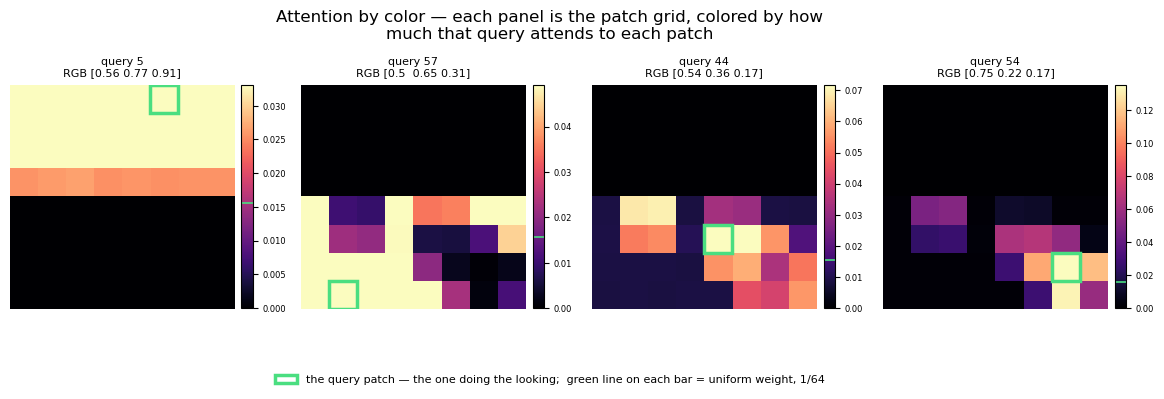

fraction of each query's attention landing on same-colored patches:
  query  5: 0.794
  query 57: 0.876
  query 44: 0.341
  query 54: 0.267

mean over all 64 queries: 0.680   (uniform attention would give 0.271)


In [16]:
W_color = selector(["R", "G", "B"])
W_value = selector(["R", "G", "B"])

out_color, A_color = attention(T, W_color, W_color, W_value, scale=0.1)


QUERY_EDGE = "#4ade80"      # the outline that marks which patch is the query


def show_attention(A, queries, title, rows=1):
    """One panel per query: its row of A, laid back onto the patch grid.

    The panels use the image's own patch layout -- cell (r, c) is image patch
    (r, c) -- but what is colored is the attention weight, not the patch's
    color. Each panel is scaled to its own peak, so read the pattern within a
    panel rather than the brightness between panels; its colorbar carries the
    actual weights, and the marked line is the uniform weight 1/N.
    """
    cols = -(-len(queries) // rows)
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.7 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, q in zip(axes, queries):
        im = ax.imshow(A[q].reshape(GRID, GRID), cmap="magma", vmin=0)
        gy, gx = divmod(q, GRID)
        ax.add_patch(plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1,
                                   fill=False, ec=QUERY_EDGE, lw=2.5))
        ax.set_title(f"query {q}\nRGB {np.round(patch_rgb[q], 2)}", fontsize=8)
        ax.axis("off")

        bar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        bar.ax.axhline(1 / N, color=QUERY_EDGE, lw=1.2)
        bar.ax.tick_params(labelsize=6)
    for ax in axes[len(queries):]:
        ax.axis("off")

    key = plt.Rectangle((0, 0), 1, 1, fill=False, ec=QUERY_EDGE, lw=2.5)
    fig.legend([key], ["the query patch — the one doing the looking;  "
                       "green line on each bar = uniform weight, 1/64"],
               loc="lower center", frameon=False, fontsize=8,
               bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(title, y=1.0)
    plt.show()


show_attention(A_color, DEMO_QUERIES,
               "Attention by color — each panel is the patch grid, colored by how\n"
               "much that query attends to each patch")

# Check: For each query, how much of
# its attention lands on patches whose color is close to its own?
def attention_on_similar(A, tol=0.12):
    color_distance = np.linalg.norm(patch_rgb[:, None, :] - patch_rgb[None, :, :], axis=-1)
    similar = color_distance < tol
    return (A * similar).sum(axis=1)

share = attention_on_similar(A_color)
print(f"fraction of each query's attention landing on same-colored patches:")
for q in DEMO_QUERIES:
    print(f"  query {q:2d}: {share[q]:.3f}")
print(f"\nmean over all {N} queries: {share.mean():.3f}   (uniform attention would give {np.mean([(np.linalg.norm(patch_rgb - patch_rgb[i], axis=-1) < 0.12).mean() for i in range(N)]):.3f})")

---
## 4. A second head (position)

In Section 3, we built an attention head that attended to color. In this section, we will build a second attention head, which will attend to the spatial **neighbors** of a patch.

### Designing the score

The **distance** between the patch and its neighbors is the natural choice for a score measure for "attending the patch's spatial neighbors". Since the score measure must use information from the two different patches (in the form of tokens), we do have the information to calculate the distance. Let Writing $p_i = (x_i, y_i)$ be a patch's position, the distance between two patches is given by:
$$
\lVert p_i - p_j \rVert^2
\;=\; -2\,(x_i x_j + y_i y_j) \;+\; \lVert p_i \rVert^2 \;+\; \lVert p_j \rVert^2.
$$

Our goal is to "attend to what is near" so the score has to be written as a quantity that **grows as two patches get closer**. However, this is the opposite behavior of the distance. Since weights come from a softmax over the scores, and softmax is monotone: a larger
score gets a larger weight. To obtain the correct behavior, we negate the distance, i.e.:
$$
s_{ij} \;=\; -\lVert p_i - p_j \rVert^2
\;=\; 2\,(x_i x_j + y_i y_j) \;-\; \lVert p_i \rVert^2 \;-\; \lVert p_j \rVert^2.
$$

With positions scaled to $[-1, 1]$, squared distance runs from $0$ for a patch
against itself up to $8$ for opposite corners. Negated, a patch scores highest
on itself, a little lower on its neighbors, and far enough below on distant
patches that the softmax leaves them near zero. 

**Note on hand-designed scores for attention**: The dot product of the color components was already a similarity measure. Distance is a dissimilarity, so it has to be inverted before we can use it an attention score. The same approach must be followed for any dissimilarity we 
use as score for attending to something.

### The projections

An attention score is $\mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j$ is a dot product, given as a sum of four products. This is also the form of score $s_{ij}$ is already in that form, each product pairing
one number from token $i$ with one from token $j$. We can then write:
$$
\mathbf{q}_i = \big[\;\sqrt{2}\,x_i,\;\; \sqrt{2}\,y_i,\;\; -\lVert p_i \rVert^2,\;\; 1\;\big]^\top,
\qquad
\mathbf{k}_j = \big[\;\sqrt{2}\,x_j,\;\; \sqrt{2}\,y_j,\;\; 1,\;\; -\lVert p_j \rVert^2\;\big]^\top
$$
so that $\mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j = 2x_ix_j + 2y_iy_j - \lVert p_i \rVert^2 - \lVert p_j \rVert^2$. The three color dimensions were dropped because this head does not use them.

With columns ordered $[\,R,\ G,\ B,\ x,\ y,\ \lVert p \rVert^2,\ 1\,]$, the projection matrices are:
$$
\mathbf{W}_q =
\begin{bmatrix}
0 & 0 & 0 & \sqrt{2} & 0 & 0 & 0\\
0 & 0 & 0 & 0 & \sqrt{2} & 0 & 0\\
0 & 0 & 0 & 0 & 0 & -1 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\qquad
\mathbf{W}_k =
\begin{bmatrix}
0 & 0 & 0 & \sqrt{2} & 0 & 0 & 0\\
0 & 0 & 0 & 0 & \sqrt{2} & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 1\\
0 & 0 & 0 & 0 & 0 & -1 & 0
\end{bmatrix}
$$

The two matrices are the same except that the last two rows are swapped. The
query carries $-\lVert p \rVert^2$ where the key carries $1$, and the other way
round, because the expansion pairs each token's squared radius against the
other's constant. Setting $\mathbf{W}_q = \mathbf{W}_k$ would compute something
else.

This is one example for which attention needs two projection matrices rather than one.

In [17]:
ix, iy, ir2, i1 = (FEATURES.index(f) for f in ("x", "y", "|p|^2", "1"))
root2 = np.sqrt(2)

Wq_local = np.zeros((4, D))
Wq_local[0, ix] = root2      # query reads  sqrt2 * x
Wq_local[1, iy] = root2      #              sqrt2 * y
Wq_local[2, ir2] = -1.0      #             -|p|^2
Wq_local[3, i1] = 1.0        #              1

Wk_local = np.zeros((4, D))
Wk_local[0, ix] = root2      # key reads    sqrt2 * x
Wk_local[1, iy] = root2      #              sqrt2 * y
Wk_local[2, i1] = 1.0        #              1
Wk_local[3, ir2] = -1.0      #             -|p|^2

used = [ix, iy, ir2, i1]
print(f"columns shown: {[FEATURES[i] for i in used]}")
print("W_q:"); print(np.round(Wq_local[:, used], 2))
print("W_k:"); print(np.round(Wk_local[:, used], 2))

# Does q . k come out as the negative squared distance?
scores = (T @ Wq_local.T) @ (T @ Wk_local.T).T
positions = T[:, [ix, iy]]
target = -((positions[:, None, :] - positions[None, :, :]) ** 2).sum(-1)

columns shown: ['x', 'y', '|p|^2', '1']
W_q:
[[ 1.41  0.    0.    0.  ]
 [ 0.    1.41  0.    0.  ]
 [ 0.    0.   -1.    0.  ]
 [ 0.    0.    0.    1.  ]]
W_k:
[[ 1.41  0.    0.    0.  ]
 [ 0.    1.41  0.    0.  ]
 [ 0.    0.    0.    1.  ]
 [ 0.    0.   -1.    0.  ]]


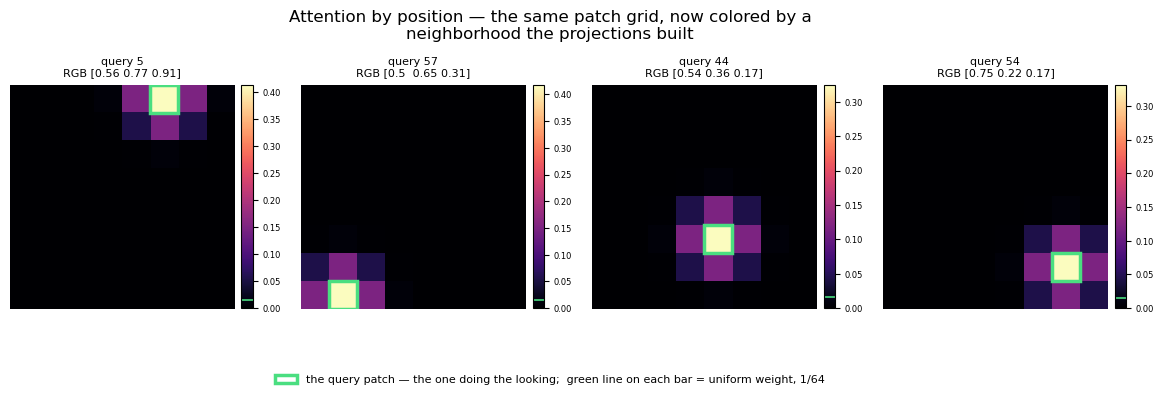

In [18]:
_, A_local = attention(T, Wq_local, Wk_local, selector(["R", "G", "B"]), scale=0.08)
show_attention(A_local, DEMO_QUERIES,
               "Attention by position — the same patch grid, now colored by a\n"
               "neighborhood the projections built")

Each query attends to a soft disc around itself: a blur kernel, built out of an
attention layer and two matrices we designed.

Note that a convolution has this neighborhood by design. A transformer has to learn it
from the data.

---
## 5. The split between $\mathbf{W}_q$ and $\mathbf{W}_k$ is arbitrary

In our designed projection matrices, the fact that we can see which dimension each row selects is not guaranteed. It only happened because we designed them this way. It is not a 
property of the head itself. The projections only meet as a product:
$$
s_{ij} \;=\; (\mathbf{W}_q \mathbf{t}_i)^{\mathsf{T}} \mathbf{W}_k \mathbf{t}_j
\;=\; \mathbf{t}_i^{\mathsf{T}} \big(\mathbf{W}_q^{\mathsf{T}} \mathbf{W}_k\big) \mathbf{t}_j
$$

Any other pair with the same product computes the same scores. For example, we can pick an invertible $\mathbf{M}$, replace $\mathbf{W}_q$ with
$\mathbf{M}^{-\mathsf{T}}\mathbf{W}_q$ and $\mathbf{W}_k$ with
$\mathbf{M}\mathbf{W}_k$, and the two $\mathbf{M}$ cancel.

In [19]:
M = rng.normal(size=(4, 4))
Wq_alt = np.linalg.inv(M).T @ Wq_local
Wk_alt = M @ Wk_local

_, A_alt = attention(T, Wq_alt, Wk_alt, selector(["R", "G", "B"]), scale=0.08)

print(f"columns shown: {[FEATURES[i] for i in used]}")
print("W_q, written by hand:"); print(np.round(Wq_local[:, used], 2))
print("W_q, rebuilt through M:"); print(np.round(Wq_alt[:, used], 2))

print(f"\nthe two projections differ:        {not np.allclose(Wq_local, Wq_alt)}")
print(f"but W_q^T W_k is the same matrix:  {np.allclose(Wq_local.T @ Wk_local, Wq_alt.T @ Wk_alt)}")
print(f"and the attention is identical:    {np.allclose(A_local, A_alt)}")
print(f"largest difference anywhere in A:  {np.abs(A_local - A_alt).max():.2e}")

columns shown: ['x', 'y', '|p|^2', '1']
W_q, written by hand:
[[ 1.41  0.    0.    0.  ]
 [ 0.    1.41  0.    0.  ]
 [ 0.    0.   -1.    0.  ]
 [ 0.    0.    0.    1.  ]]
W_q, rebuilt through M:
[[-2.    1.82  0.54  0.71]
 [-1.11  1.44 -0.03  0.62]
 [ 0.44  0.07  0.32 -1.15]
 [-1.37  0.57 -0.04  0.43]]

the two projections differ:        True
but W_q^T W_k is the same matrix:  True
and the attention is identical:    True
largest difference anywhere in A:  6.27e-15


The difference is floating-point noise. The two layers are the same layer.

As a result, we cannot interpret a trained $\mathbf{W}_q$ on its own as "what token $i$
looks for" and $\mathbf{W}_k$ as "what token $j$ offers". The split between
them is arbitrary. Asking what a trained $\mathbf{W}_q$ means by itself is similar to  
asking what the $3$ means in $12 = 3 \times 4$, because we could as well have written
$6 \times 2$.

Only the product is a property of the model.

---
## 6. The output token

Sections 3 to 5 built $\mathbf{A}$, which are attention maps. But $\mathbf{A}$
is not the layer. The layer is $\mathbf{A}\mathbf{V}$, and that is what the next
layer receives.

Each token offers a **value**, its own code vector under the third projection,

$$
\mathbf{v}_j \;=\; \mathbf{W}_v \mathbf{t}_j
$$

and the output at position $i$ is those values, weighted by how much $i$ attended
to each:

$$
\mathbf{T}_{\texttt{out}}[i,:] \;=\; \sum_{j=1}^{N} \mathbf{A}[i,j]\, \mathbf{v}_j^{\mathsf{T}}
$$

One output token per input token, each a **weighted blend of other tokens'
content**.

The output token at position $i$ is no longer a
description of patch $i$; it is a mixture of whatever patch $i$ looked at, and
the only thing tying it to its original patch is where it sits in the array. 

$\mathbf{W}_v$ decides what gets blended. Its width is free, too: queries and keys must share a width $m$ because
they meet in a dot product, but nothing constrains the values that way, and
whatever width $\mathbf{W}_v$ maps to becomes the width of the layer's output.

### What each head produces

We have built two heads. Each computes $\mathbf{A}\mathbf{V}$ once, with its own
attention and its own values, and hands the result on. That is the whole of what
a head does.

Both carry the patch's color as their value, so each output is a set of 64
colors — one per patch, as the input was.

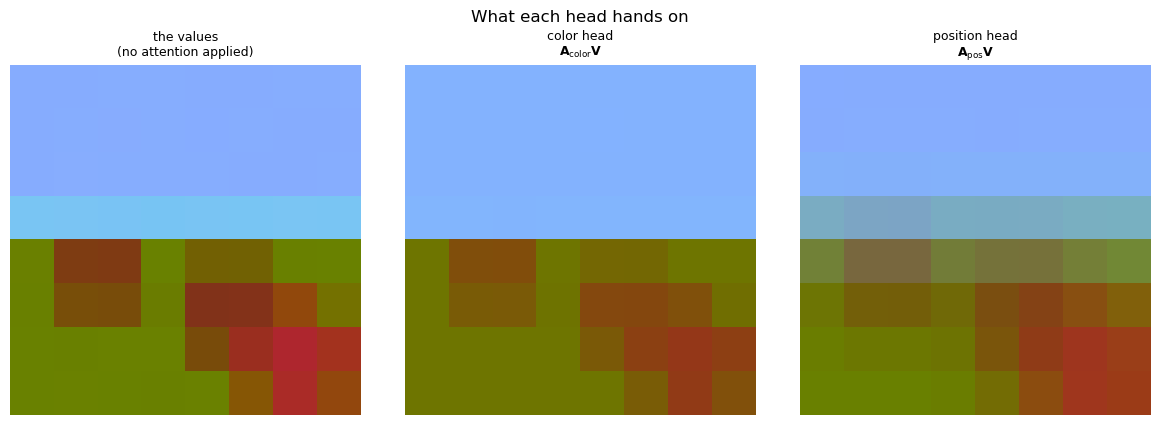

every panel is 3 numbers per patch, 64 patches
inputs and outputs have the same shape: (64, 3) -> (64, 3)


In [20]:
V = T @ W_value.T                 # one value per token: its color

out_color = A_color @ V           # the color head   (Section 3 computed this already)
out_local = A_local @ V           # the position head (Section 4)


def as_image(values):
    """Render N x 3 values as an 8 x 8 picture, shifted and scaled to fill [0, 1]."""
    shifted = values - values.min()
    return (shifted / max(shifted.max(), 1e-9)).reshape(GRID, GRID, 3)


fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, data, title in [
    (axes[0], V,         "the values\n(no attention applied)"),
    (axes[1], out_color, "color head\n$\\mathbf{A}_{\\mathrm{color}}\\mathbf{V}$"),
    (axes[2], out_local, "position head\n$\\mathbf{A}_{\\mathrm{pos}}\\mathbf{V}$"),
]:
    ax.imshow(as_image(data)); ax.set_title(title, fontsize=9); ax.axis("off")
fig.suptitle("What each head hands on", y=1.0)
plt.tight_layout(); plt.show()

print(f"every panel is {V.shape[1]} numbers per patch, {V.shape[0]} patches")
print(f"inputs and outputs have the same shape: {V.shape} -> {out_color.shape}")

The left panel is the values before any mixing: each patch holding its own color
and nothing else. The other two are the outputs.

**The color head produces a flattened image.** Each patch attended to its
color-alikes wherever they sat, so each output token reports the mean color of
its group rather than its own. The mixed sky-and-grass band along the horizon
has merged into the sky; the animals have drawn together. Nothing moved
spatially — an output token still sits where its patch sat — but what it holds
is now a property of a group.

**The position head produces a blurred image.** Each patch attended to its
spatial neighbors regardless of color, so each output token holds the local
average. Edges soften and the flower bleeds into the grass around it. This is
the convolution of Section 4, seen as something done to an image rather than as
an attention map.

In both, an output token holds content that was never in the input token at that
position. That is what $\mathbf{A}\mathbf{V}$ does.

### Attention cannot count

The blend is a weighted average, never a sum. A layer cannot give a sum, i.e., how *many* patches a
query attended to. Read the constant feature as the value, and the answer ought
to be a count.

In [21]:
# What happens if we ask it to count? Read the constant feature as the value.
counts = A_color @ (T @ selector(["1"]).T)

print(f"value = the constant 1, for four different queries:")
for q in DEMO_QUERIES:
    print(f"  query {q:2d}: {counts[q, 0]:.6f}")
print(f"\nevery row of A sums to one: {np.allclose(A_color.sum(axis=1), 1.0)}")

value = the constant 1, for four different queries:
  query  5: 1.000000
  query 57: 1.000000
  query 44: 1.000000
  query 54: 1.000000

every row of A sums to one: True


Every query returns exactly $1$, whichever patches it attended to: the weighted
average of a constant is that constant, whatever weights you use.

The count is not lost in the blend, though. It is computed, used, and then
divided away — and the thing it is divided by is the softmax's own denominator:

$$
\mathbf{A}[i,j] \;=\; \frac{e^{\,s_{ij}}}{\underbrace{\textstyle\sum_k e^{\,s_{ik}}}_{\textstyle Z_i}}
$$

$Z_i$ is a soft count of how much query $i$ found worth attending to. Dividing
by it is exactly what forces every row to sum to one, so it is exactly what
makes the count unreachable afterwards. No choice of $\mathbf{W}_v$ repairs
that, because the division happened before the values were consulted.

In [22]:
# Z is the softmax denominator for each query of the position head.
E = np.exp((T @ Wq_local.T) @ (T @ Wk_local.T).T / 0.08)   # unnormalized weights
Z = E.sum(axis=1)

print("the softmax denominator Z, for three patches of the position head:")
for label, q in [("corner", 0), ("edge", 4), ("interior", 3 * GRID + 3)]:
    print(f"  {label:9s} {Z[q]:5.2f}")
print(f"\n  interior / corner: {Z[3 * GRID + 3] / Z[0]:.2f}x  — an interior patch has more"
      f" neighbors within range")
print(f"\nafter dividing by Z, every row totals the same: {np.allclose((E / Z[:, None]).sum(1), 1.0)}")

the softmax denominator Z, for three patches of the position head:
  corner     1.90
  edge       2.42
  interior   3.08

  interior / corner: 1.62x  — an interior patch has more neighbors within range

after dividing by Z, every row totals the same: True


That is the trade normalization makes: output magnitudes that stay stable
however long the sequence, at the cost of ever representing *how much* was
attended to.

The chapter's safari example *does* count — four animal heads, read out of the
output token — because that figure is drawn with the softmax left out, so its
weights are $1$ on the attended tokens rather than $\tfrac{1}{4}$ each. Keeping
the count means keeping unnormalized weights: omit the softmax, as the figure
does, or use a per-element sigmoid in place of a row-wise softmax, as some
architectures do.

So the layer hands on a set of tokens the same shape as the ones it received —
64 patches in, 64 out — and not one of them describes the patch it replaced.

---
## 7. The scale factor is a temperature

Notebook 4 Section 5.4 argues for the $\sqrt{m}$ from the variance of the dot
product. Here is the same thing to look at.

Divide the scores by a large number and every row of $\mathbf{A}$ approaches
uniform: attention averages everything and distinguishes nothing. Divide by a
small number and each row approaches one-hot: attention becomes a hard lookup
of a single patch.

Attention is a **soft dictionary**, and the scale is its temperature. The
$\sqrt{m}$ is the setting that keeps a freshly initialized model off both
extremes — away from the uniform end where it says nothing, and away from the
saturated end where $\alpha(1-\alpha) \approx 0$ and no gradient flows.

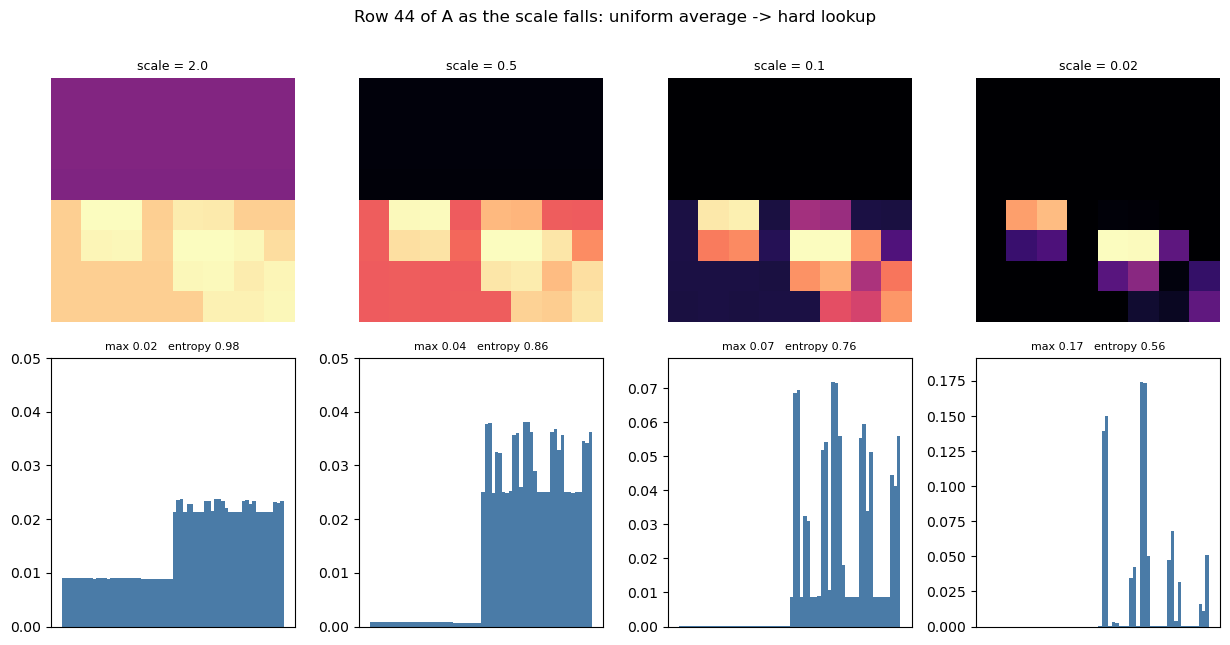

entropy is normalized to [0, 1]: 1 means uniform over all 64 patches,
0 means all the attention sits on one patch.


In [23]:
scales = [2.0, 0.5, 0.1, 0.02]
query = DEMO_QUERIES[2]      # the animal patch

fig, axes = plt.subplots(2, len(scales), figsize=(3.1 * len(scales), 6.4))
for col, scale in enumerate(scales):
    _, A_s = attention(T, W_color, W_color, W_value, scale=scale)
    row = A_s[query]

    axes[0, col].imshow(row.reshape(GRID, GRID), cmap="magma", vmin=0)
    axes[0, col].set_title(f"scale = {scale}", fontsize=9); axes[0, col].axis("off")

    entropy = -(row * np.log(row + 1e-12)).sum() / np.log(N)
    axes[1, col].bar(range(N), row, width=1.0, color="#4a7ba7")
    axes[1, col].set_ylim(0, max(row.max() * 1.1, 0.05))
    axes[1, col].set_title(f"max {row.max():.2f}   entropy {entropy:.2f}", fontsize=8)
    axes[1, col].set_xticks([])

fig.suptitle(f"Row {query} of A as the scale falls: uniform average -> hard lookup", y=1.0)
plt.tight_layout(); plt.show()

print("entropy is normalized to [0, 1]: 1 means uniform over all 64 patches,")
print("0 means all the attention sits on one patch.")

---
## 8. Remarks

**$\mathbf{W}_q$ and $\mathbf{W}_k$ are one object in two parts.** Only their
product reaches the output, so the split between them is arbitrary and a trained
$\mathbf{W}_q$ means nothing read on its own.

**They have to be two matrices, not one used twice.** The position head needed
the query to carry $-\lVert p \rVert^2$ exactly where the key carried $1$. Tie
them together and that pairing is gone.

**$\mathbf{W}_v$ is independent of both.** Where to look and what to bring back
are separate decisions, which is why multi-head attention can run several
notions of similarity in parallel and still combine their payloads at the end.